In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("heart_disease_uci.csv")  

In [5]:
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [7]:
df.shape

(920, 16)

In [8]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [9]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [10]:
df_copy  = df.copy()

In [11]:
df_copy.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [12]:
df_copy.dropna(subset=["fbs", "exang"], inplace=True)

In [13]:
df_copy.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps      3
chol         27
fbs           0
restecg       1
thalch        0
exang         0
oldpeak       4
slope       234
ca          471
thal        371
num           0
dtype: int64

In [ ]:
df_copy.dropna(subset=["trestbps", "restecg","oldpeak"], inplace=True)

In [15]:
df_copy.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps      0
chol         27
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope       228
ca          463
thal        366
num           0
dtype: int64

In [16]:
df_copy['chol'] = df_copy['chol'].fillna(df_copy['chol'].mean())

In [17]:
df_copy['ca'] = df_copy['ca'].fillna(df_copy['ca'].mean())

In [18]:
df_copy.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope       228
ca            0
thal        366
num           0
dtype: int64

In [19]:
df.thal.unique()

<StringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str

In [20]:
df.slope.unique()

<StringArray>
['downsloping', 'flat', 'upsloping', nan]
Length: 4, dtype: str

In [21]:
df_copy['slope'] = df_copy["slope"].fillna(df_copy["slope"].mode()[0], inplace=True)

C:\Users\wwwzb\AppData\Local\Temp\ipykernel_1688\3420096304.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_copy['slope'] = df_copy["slope"].fillna(df_copy["slope"].mode()[0], inplace=True)


In [22]:
df_copy.isnull().sum()


id            0
age           0
sex           0
dataset       0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca            0
thal        366
num           0
dtype: int64

In [23]:
df_copy.drop(columns=["thal"], inplace=True)

In [24]:
df_copy.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
num         0
dtype: int64

In [25]:
df.dtypes

id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

In [26]:
df_copy.dtypes

id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
num           int64
dtype: object

In [27]:
df_copy.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,0


In [28]:
print(df_copy["fbs"].unique())
print(df_copy["exang"].unique())

[True False]
[False True]


In [29]:
df_copy["fbs"] = df_copy["fbs"].astype(int)
df_copy["exang"] = df_copy["exang"].astype(int)

In [30]:
df_copy.dtypes

id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs           int64
restecg         str
thalch      float64
exang         int64
oldpeak     float64
slope           str
ca          float64
num           int64
dtype: object

In [31]:
df_copy.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,1,lv hypertrophy,150.0,0,2.3,downsloping,0.0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,0,lv hypertrophy,108.0,1,1.5,flat,3.0,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,0,lv hypertrophy,129.0,1,2.6,flat,2.0,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0.0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,0,lv hypertrophy,172.0,0,1.4,upsloping,0.0,0


In [32]:
# num_cols= df_copy.select_dtypes(include=['int64','float64']).columns

In [33]:
df_copy.columns


Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'num'],
      dtype='str')

In [34]:
df.dtypes

id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

In [35]:
# Numeric columns (exclude fbs and exang)
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

# Categorical columns
cat_cols = ["sex", "cp", "restecg", "slope","dataset"]

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_copy[num_cols] = scaler.fit_transform(df_copy[num_cols])

In [37]:
df_copy.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,num
0,1,1.058104,Male,Cleveland,typical angina,0.658037,0.139988,1,lv hypertrophy,0.438254,0,1.310060,downsloping,-1.126768,0
1,2,1.481843,Male,Cleveland,asymptomatic,1.465666,0.716765,0,lv hypertrophy,-1.191989,1,0.570749,flat,3.985730,2
2,3,1.481843,Male,Cleveland,asymptomatic,-0.688011,0.096458,0,lv hypertrophy,-0.376868,1,1.587302,flat,2.281564,1
3,4,-1.696198,Male,Cleveland,non-anginal,-0.149592,0.324992,0,normal,1.874419,0,2.419027,downsloping,-1.126768,0
4,5,-1.272460,Female,Cleveland,atypical angina,-0.149592,-0.175607,0,lv hypertrophy,1.292190,0,0.478335,upsloping,-1.126768,0


In [38]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoder_arr = encoder.fit_transform(df_copy[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)

encoded_df = pd.DataFrame(encoder_arr, columns=encoded_cols)

In [39]:
# Drop original categorical columns
df_copy = df_copy.drop(columns=cat_cols)

# Concatenate one-hot encoded columns directly
df_copy = pd.concat([df_copy, encoded_df], axis=1)

df_copy.head()

,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,...,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach
0,1.0,1.058104,0.658037,0.139988,1.0,0.438254,0.0,1.310060,-1.126768,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2.0,1.481843,1.465666,0.716765,0.0,-1.191989,1.0,0.570749,3.985730,2.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,3.0,1.481843,-0.688011,0.096458,0.0,-0.376868,1.0,1.587302,2.281564,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,-1.696198,-0.149592,0.324992,0.0,1.874419,0.0,2.419027,-1.126768,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,-1.272460,-0.149592,-0.175607,0.0,1.292190,0.0,0.478335,-1.126768,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [40]:
df_copy["num"] = df_copy["num"].apply(lambda x: 0 if x == 0 else 1)

df_copy["num"].value_counts()

num
1    489
0    375
Name: count, dtype: int64

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [42]:
df_copy.dropna(inplace=True)

In [43]:
df_copy.isnull().sum()

id                          0
age                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
num                         0
sex_Female                  0
sex_Male                    0
cp_asymptomatic             0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_lv hypertrophy      0
restecg_normal              0
restecg_st-t abnormality    0
slope_downsloping           0
slope_flat                  0
slope_upsloping             0
dataset_Cleveland           0
dataset_Hungary             0
dataset_Switzerland         0
dataset_VA Long Beach       0
dtype: int64

In [44]:
X = df_copy.drop(columns=["num"])
y = df_copy["num"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
model = LogisticRegression()
model.fit(X_train, y_train) 


c:\Users\wwwzb\OneDrive\Desktop\DHC\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
y_hat = model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [49]:
print("Accuracy:", accuracy_score(y_test, y_hat))

Accuracy: 0.8805970149253731


C:\Users\wwwzb\AppData\Local\Temp\ipykernel_1688\4108627501.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="num", data=df_copy,palette="Set2")


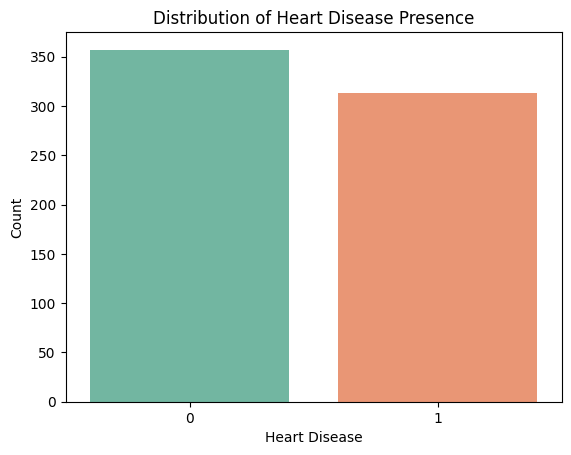

In [50]:
sns.countplot(x="num", data=df_copy,palette="Set2")
plt.title("Distribution of Heart Disease Presence")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

In [51]:
print(df_copy.index)
print(encoded_df.index)

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       753, 754, 755, 757, 759, 760, 761, 763, 765, 766],
      dtype='int64', length=670)
RangeIndex(start=0, stop=767, step=1)


In [52]:
from sklearn.metrics import classification_report, confusion_matrix

In [53]:
# --- 7.2 Classification Report ---
print('\nCLASSIFICATION REPORT:')
print('='*50)
print(classification_report(y_test, y_hat, target_names=['No Disease', 'Heart Disease']))


CLASSIFICATION REPORT:
               precision    recall  f1-score   support

   No Disease       0.90      0.88      0.89        72
Heart Disease       0.86      0.89      0.87        62

     accuracy                           0.88       134
    macro avg       0.88      0.88      0.88       134
 weighted avg       0.88      0.88      0.88       134



In [54]:
cm= confusion_matrix(y_test, y_hat)
print('\nCONFUSION MATRIX:')
print('='*50)
print(cm)



CONFUSION MATRIX:
[[63  9]
 [ 7 55]]


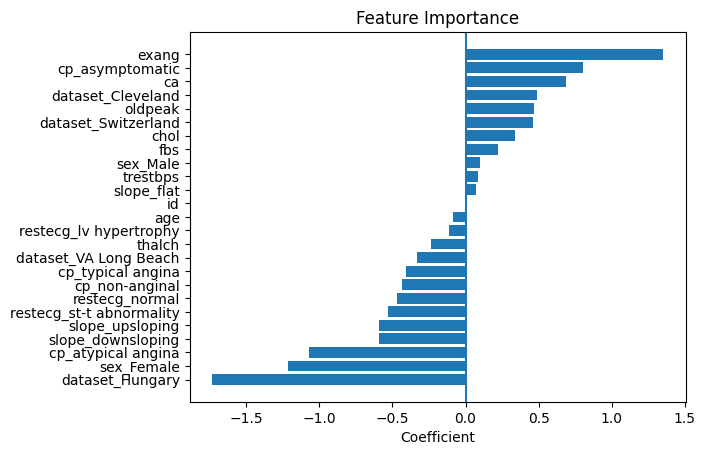

Top positive features:
              Feature  Coefficient
7             oldpeak     0.467052
21  dataset_Cleveland     0.489388
8                  ca     0.689264
11    cp_asymptomatic     0.806694
6               exang     1.350918

Top negative features:
               Feature  Coefficient
22     dataset_Hungary    -1.732793
9           sex_Female    -1.213231
12  cp_atypical angina    -1.072884
18   slope_downsloping    -0.592532
20     slope_upsloping    -0.589091


In [55]:
# Feature importance

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient")

# Plot
plt.barh(coeff_df["Feature"], coeff_df["Coefficient"])
plt.axvline(0)

plt.xlabel("Coefficient")
plt.title("Feature Importance")
plt.show()

# Top features
print("Top positive features:")
print(coeff_df.tail(5))

print("\nTop negative features:")
print(coeff_df.head(5))